<a href="https://colab.research.google.com/github/MariaReyesMedina/DACSS690C_Computation_SocialSci_Methods/blob/main/MariaCopia_de_indexH1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [123]:

!wget https://github.com/MariaReyesMedina/DACSS690C_Computation_SocialSci_Methods/raw/main/PeruMaps.gpkg

--2026-07-14 22:32:11--  https://github.com/MariaReyesMedina/DACSS690C_Computation_SocialSci_Methods/raw/main/PeruMaps.gpkg
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/MariaReyesMedina/DACSS690C_Computation_SocialSci_Methods/main/PeruMaps.gpkg [following]
--2026-07-14 22:32:12--  https://raw.githubusercontent.com/MariaReyesMedina/DACSS690C_Computation_SocialSci_Methods/main/PeruMaps.gpkg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60784640 (58M) [application/octet-stream]
Saving to: ‘PeruMaps.gpkg.3’

PeruMaps.gpkg.3     100%[===================>]  57.97M   174MB/s    in 0.3s    

2026-0

1. Install and activate libraries needed.

In [124]:

import geopandas as gpd
#Library for handling maps/Librería para manejar mapas

import libpysal
# Library for spatial operations/Librería para operaciones espaciales

from esda.moran import Moran_Local
# Spatial statistics methods (LISA)/Métodos de estadística espacial (LISA)

import matplotlib.pyplot as plt
# For graphics/ Para gráficos

import numpy as np
# To create categories/ Para crear categorías

2. Read the map of Peru (same layer used in class)

In [125]:

peru = gpd.read_file(
    "PeruMaps.gpkg",
    layer="good_geom"
)
peru.head()

#Read the "good_geom" layer from the GeoPackage. This layer contains the district polygons and their attributes.


,DEPARTAMENTO,PROVINCIA,DISTRITO,ubigeo,Poblacion,IDH2019,Educ_sec_comp2019_pct,NBI2017_pct,Viv_sin_serv_hig2017_pct,geometry
0,Apurimac,ABANCAY,ABANCAY,PE030101,56871,0.600375,78.865450,15.8,2.9,"MULTIPOLYGON (((-72.93158 -13.55616, -72.9314 ..."
1,Ancash,BOLOGNESI,ABELARDO PARDO LEZAMETA,PE020502,1263,0.434687,50.434603,33.6,25.4,"MULTIPOLYGON (((-77.1474 -10.29675, -77.14643 ..."
2,Arequipa,CARAVELI,ACARI,PE040302,3010,0.634185,56.273614,26.2,8.8,"MULTIPOLYGON (((-74.61542 -15.13728, -74.61174..."
3,Ancash,OCROS,ACAS,PE021402,1057,0.469140,72.527156,70.4,67.6,"MULTIPOLYGON (((-77.26312 -10.43537, -77.26356..."
4,Cusco,PARURO,ACCHA,PE081002,3839,0.300626,64.586647,28.6,11.1,"MULTIPOLYGON (((-71.80912 -13.92427, -71.80901..."


3. Verify if the map is projected, otherwise use CRS '5387'.

In [126]:
peru.crs
#To check the current coordinate reference system/Ver el sistema de coordenadas actual

peru.crs.is_projected
# To check if the map is already projected/ Ver si está proyectado


False

In [127]:
peru = peru.to_crs("EPSG:5387")

#Like is not projected we need to traform it to CRS 5387/ Transformar a CRS proyectado 5387

4. Keep the DEPARTAMENTO of 'LIMA'.

In [135]:

lima = peru[
    peru["DEPARTAMENTO"] == "Lima"
].copy()
lima.head()

#To select only districts belonging to the department of Lima AND avoid error inthe future with .copy/ Seleccionar únicamente el departamento de Lima


,DEPARTAMENTO,PROVINCIA,DISTRITO,ubigeo,Poblacion,IDH2019,Educ_sec_comp2019_pct,NBI2017_pct,Viv_sin_serv_hig2017_pct,geometry
39,Lima,YAUYOS,ALIS,PE151002,1233,0.646897,69.474298,30.3,6.6,"MULTIPOLYGON (((415396.076 8647591.116, 415450..."
40,Lima,YAUYOS,AYAUCA,PE151003,2293,0.544152,43.167400,61.9,57.2,"MULTIPOLYGON (((389530.693 8626520.884, 389743..."
54,Lima,HUAURA,AMBAR,PE150802,2761,0.316448,42.060097,73.3,60.2,"MULTIPOLYGON (((243293.978 8826436.11, 243328...."
65,Lima,LIMA,ANCON,PE150102,42124,0.668889,72.117976,21.7,1.1,"MULTIPOLYGON (((281417 8715329, 281397.439 871..."
71,Lima,OYON,ANDAJES,PE150902,1058,0.488913,71.684369,36.4,28.5,"MULTIPOLYGON (((291522.945 8820149.937, 291499..."


5. Produce the LISA MAP using the normalized neighborhood  matrix (or weights matrix) using the QUEEN criterion

AND

6. Rename numeric LISA categories into meaningful labels


In [129]:
from libpysal.weights import Queen

w_queen = Queen.from_dataframe(lima)

#To create spatial weights using Queen contiguity (two districts are neighbors if they shaere an edge or a corner)/Crear matriz de vecinos usando criterio Queen

w_queen.transform = "R"

#We have to normalize the weights matrix, each neighbor should receives a proportional weight/ Convertir pesos a proporciones, es decir "normalizar" significa que cada vecino la misma importacia relativa

variable = lima["NBI2017_pct"]

#To the analysis I gonna use the variable NBI2017_pct that represents the percentage of people with unsatisfied basic needs in each district.


lisa_queen = Moran_Local(
    variable,
    w_queen
)
# To calculate Local Moran´s I LISA/ para calcular LISA




/tmp/ipykernel_1708/1256371195.py:3: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = Queen.from_dataframe(lima)


In [130]:
lima["Lisa_queen"] = lisa_queen.q

#LISA categories

In [131]:
lima["Lisa_queen"] = lima["Lisa_queen"].map({
    1:"High-High",
    2:"Low-High",
    3:"Low-Low",
    4:"High-Low"
})

#To rename numeric LISA categories in labels/ Renombrar no numeros, si se omite el mapa sale con escala de numeros


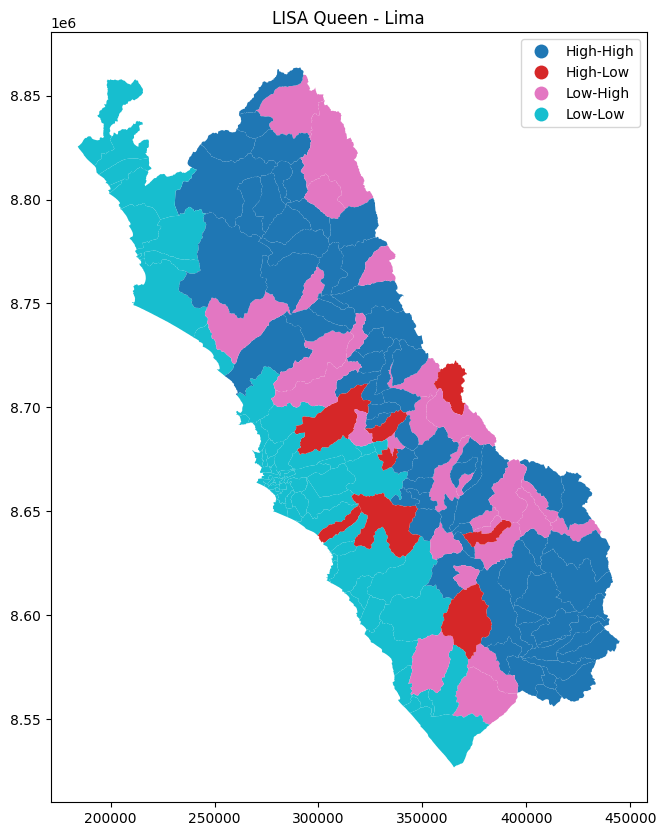

In [132]:
lima.plot(
    column="Lisa_queen",
    legend=True,
    figsize=(10,10)
)

plt.title("LISA Queen - Lima")
plt.show()

#Plot Queen LISA map

7. Redo the LISA MAP, using a  KNN neighborhood  matrix (K = 8).  The new column will be "Lisa_knn8"

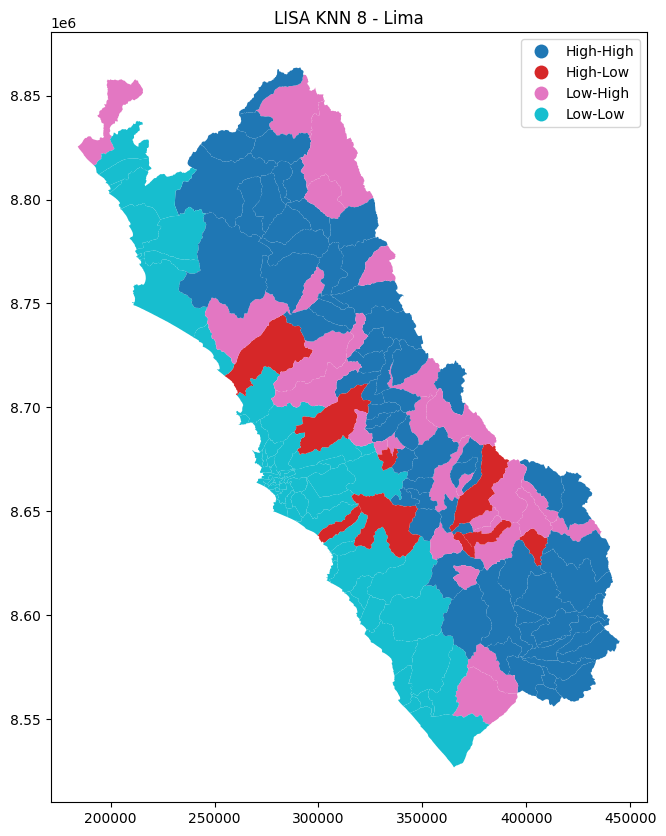

In [133]:
from libpysal.weights import KNN

w_knn8 = KNN.from_dataframe(
    lima,
    k=8
)

# To create K-nearest neighbors weights (each district will have the 8 closest districts as neighbors/ Esto crea vecinos usando los 8 más cercanos


w_knn8.transform = "R"

# Normalize/Normalizar

lisa_knn8 = Moran_Local(
    lima["NBI2017_pct"],
    w_knn8
)

#Calculate LISA using KNN weights

lima["Lisa_knn8"] = lisa_knn8.q

#Save categories

lima["Lisa_knn8"] = lima["Lisa_knn8"].map({
    1:"High-High",
    2:"Low-High",
    3:"Low-Low",
    4:"High-Low"
})

#Replace numbers with LISA category names

lima.plot(
    column="Lisa_knn8",
    legend=True,
    figsize=(10,10)
)

plt.title("LISA KNN 8 - Lima")
plt.show()

# Plot KNN LISA map

8. REPORT: Compare if any district does not belong to the same group when using Queen vs. KNN

In [134]:
comparison = lima[
    lima["Lisa_queen"] != lima["Lisa_knn8"]
]

comparison[
    ["DISTRITO","Lisa_queen","Lisa_knn8"]
]

# Identify districts where Queen and KNN produce different categories


,DISTRITO,Lisa_queen,Lisa_knn8
115,AUCALLAMA,High-High,High-Low
227,CARANIA,High-High,High-Low
324,CHICLA,High-Low,High-High
597,HUAMPARA,High-High,High-Low
1141,PARAMONGA,Low-Low,Low-High
1290,QUILMANA,Low-High,Low-Low
1447,SAN LORENZO DE QUINTI,High-High,High-Low
1459,SAN MATEO DE OTAO,High-Low,High-High
1530,SANTA CRUZ DE COCACHACRA,Low-Low,Low-High
1698,TAURIPAMPA,High-Low,High-High
